In [47]:
import numpy as np
import glob
import open3d as o3d
import cv2
import matplotlib.pyplot as plt

In [48]:
path_117322070663 = "./mask/117322070663/*.ply"
path_108322073284 = "./mask/108322073284/*.ply"

In [49]:
camera_params = {
    "117322070663": {
        "K": np.array([[591.2588416325026, 0.0, 303.96766080041255], [0.0, 582.3094248920196, 253.6549343618132], [0.0, 0.0, 1.0]]),
        "D": np.array([0.0857423535202526, 0.15899390827577137, 0.0027644426081692413, -0.014441335296417794, -1.3507539704153515])
    },
    "108322073284": {
        "K": np.array([[581.4988972720037, 0.0, 339.4397798655603], [0.0, 582.8600048067065, 282.73657769938495], [0.0, 0.0, 1.0]]),
        "D": np.array([-0.24057957220615858, 4.2767106826695604, 0.024711451849462666, 0.013758143071840522, -20.808592661502967])
    }
}

R = np.array([
    [-0.0326154191220418, 0.6047670517721788, -0.7957342819850609],
    [-0.581149899271677, 0.6362593173876714, 0.5073843470327937],
    [0.8131426867481583, 0.47898945095707646, 0.3307084469133276]
])

t = np.array([0.26853285220651585, -0.174979423376861, 0.1982699183045584]).reshape(3, 1)

In [50]:
Rt = np.array([
    [-0.0326154191220418, 0.6047670517721788, -0.7957342819850609, 0.26853285220651585],
    [-0.581149899271677, 0.6362593173876714, 0.5073843470327937, -0.174979423376861],
    [0.8131426867481583, 0.47898945095707646, 0.3307084469133276, 0.1982699183045584],
    [0, 0, 0, 1]
], dtype=float)

In [51]:
def camera_to_image(K, ptc, name="Depth Map"):
    X = ptc[:, 0]
    Y = ptc[:, 1]
    Z = ptc[:, 2]

    Z_abs = np.abs(Z)

    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    
    u = ((fx * X) / Z_abs) + cx
    v = ((fy * Y) / Z_abs) + cy

    depth_map = np.zeros((480, 640))
    u_int = np.round(u).astype(int)
    v_int = np.round(v).astype(int)
    
    mask = (u_int >= 0) & (u_int < 640) & (v_int >= 0) & (v_int < 480)
    
    depth_map[v_int[mask], u_int[mask]] = Z_abs[mask]
    
    depth_map[depth_map == 0] = np.nan

    plt.figure(figsize=(8, 6))
    img = plt.imshow(depth_map, cmap='jet')
    plt.colorbar(img, label='Distanza (m)')
    plt.title(name)
    plt.show()

    return u, v

In [52]:
camera_117322070663 = []

for element in glob.glob(path_117322070663):
    pcd = o3d.io.read_point_cloud(element)
    points = np.asarray(pcd.points)

    camera_117322070663.append(points)

In [53]:
camera_108322073284 = []

for element in glob.glob(path_108322073284):
    pcd = o3d.io.read_point_cloud(element)
    points = np.asarray(pcd.points)

    camera_108322073284.append(points)

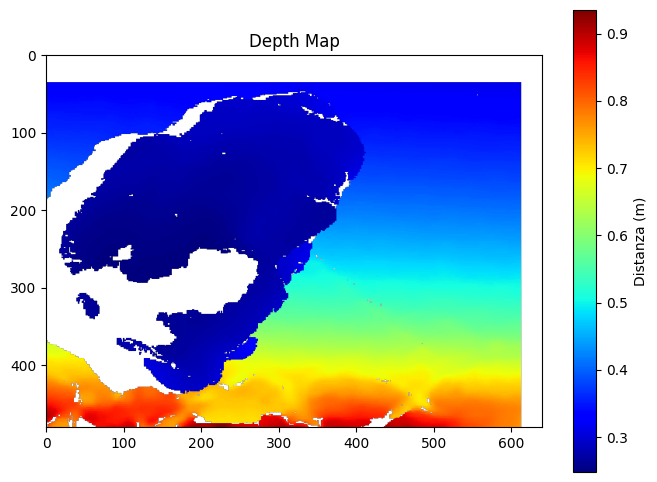

In [54]:
for element in camera_117322070663:
    u, v = camera_to_image(camera_params["117322070663"]["K"], element)

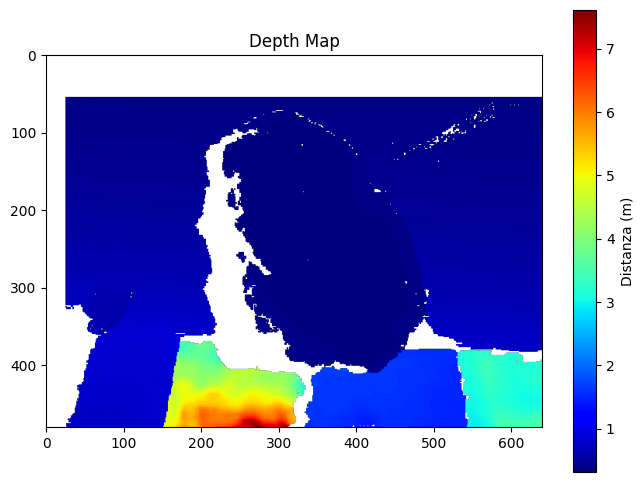

In [55]:
for element in camera_108322073284:
    u, v = camera_to_image(camera_params["108322073284"]["K"], element)

In [61]:
import os
import re

def _idx_from_name(path):
    m = re.search(r'_(\d+)\.ply$', os.path.basename(path))
    return int(m.group(1)) if m else None

def _files_by_idx(pattern):
    files = glob.glob(pattern)
    out = {}
    for f in files:
        idx = _idx_from_name(f)
        if idx is not None:
            out[idx] = f
    return out

def _largest_cluster(pcd, eps=0.03, min_points=120):
    if len(pcd.points) == 0:
        return pcd
    labels = np.array(pcd.cluster_dbscan(eps=eps, min_points=min_points, print_progress=False))
    if labels.size == 0 or labels.max() < 0:
        return pcd
    best_label = np.bincount(labels[labels >= 0]).argmax()
    idx = np.where(labels == best_label)[0]
    return pcd.select_by_index(idx)

def _prep_pcd(points, voxel=0.004):
    mask = np.isfinite(points).all(axis=1)
    pts = points[mask]
    if pts.shape[0] == 0:
        return o3d.geometry.PointCloud()

    # Trim only extreme radial outliers (keep object + nearby support)
    d = np.linalg.norm(pts, axis=1)
    lo = np.quantile(d, 0.01)
    hi = np.quantile(d, 0.99)
    pts = pts[(d >= lo) & (d <= hi)]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd = pcd.voxel_down_sample(voxel_size=voxel)

    # Remove isolated noise and keep principal object cluster
    pcd, _ = pcd.remove_statistical_outlier(nb_neighbors=30, std_ratio=2.0)
    pcd = _largest_cluster(pcd, eps=0.03, min_points=120)
    return pcd

def _make_T(Rm, tv):
    Tm = np.eye(4)
    Tm[:3, :3] = Rm
    Tm[:3, 3] = tv.reshape(3)
    return Tm

def _icp_refine(source_pcd, target_pcd, T_init, max_corr=0.06):
    reg = o3d.pipelines.registration.registration_icp(
        source_pcd, target_pcd, max_corr, T_init,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=120)
    )
    return reg

def compare_and_show(frame_position=0):
    m117 = _files_by_idx(path_117322070663)
    m108 = _files_by_idx(path_108322073284)
    common = sorted(set(m117.keys()) & set(m108.keys()))

    if len(common) == 0:
        print('Nessun frame in comune tra le due cartelle.')
        return

    frame_position = max(0, min(frame_position, len(common) - 1))
    idx = common[frame_position]

    p117 = np.asarray(o3d.io.read_point_cloud(m117[idx]).points)
    p108 = np.asarray(o3d.io.read_point_cloud(m108[idx]).points)

    tgt = _prep_pcd(p117)
    src = _prep_pcd(p108)

    n_tgt = np.asarray(tgt.points).shape[0]
    n_src = np.asarray(src.points).shape[0]
    print(f'Frame idx: {idx}')
    print(f'Prepared points -> target(117): {n_tgt}, source(108): {n_src}')

    if n_tgt < 500 or n_src < 500:
        print('Punti ancora troppo pochi dopo preprocessing.')
        print('Riduci aggressivita: voxel piu piccolo o DBSCAN eps maggiore.')
        return

    # Extrinsic candidates
    T_direct = _make_T(R, t)
    R_inv = R.T
    t_inv = -R.T @ t
    T_inverse = _make_T(R_inv, t_inv)

    # Coarse centroid alignment to help ICP converge
    c_tgt = np.asarray(tgt.points).mean(axis=0)
    c_src = np.asarray(src.points).mean(axis=0)
    T_cent = np.eye(4)
    T_cent[:3, 3] = c_tgt - c_src

    reg_d = _icp_refine(src, tgt, T_cent @ T_direct, max_corr=0.06)
    reg_i = _icp_refine(src, tgt, T_cent @ T_inverse, max_corr=0.06)

    use_inverse = (reg_i.inlier_rmse < reg_d.inlier_rmse) or (
        abs(reg_i.inlier_rmse - reg_d.inlier_rmse) < 1e-6 and reg_i.fitness > reg_d.fitness
    )
    best = reg_i if use_inverse else reg_d
    direction = 'inverse (117<-108)' if use_inverse else 'direct (108->117)'

    print(f'Direct  -> fitness: {reg_d.fitness:.4f}, rmse: {reg_d.inlier_rmse:.4f}')
    print(f'Inverse -> fitness: {reg_i.fitness:.4f}, rmse: {reg_i.inlier_rmse:.4f}')
    print(f'Best: {direction}')

    src_vis = o3d.geometry.PointCloud(src)
    src_vis.transform(best.transformation)
    src_vis.paint_uniform_color([1.0, 0.2, 0.2])

    tgt_vis = o3d.geometry.PointCloud(tgt)
    tgt_vis.paint_uniform_color([0.1, 0.7, 1.0])

    frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1)
    o3d.visualization.draw_geometries(
        [tgt_vis, src_vis, frame],
        window_name=f'Best overlay frame {idx} - {direction}'
    )

compare_and_show(frame_position=0)

Frame idx: 0
Prepared points -> target(117): 23337, source(108): 20542
Direct  -> fitness: 0.0000, rmse: 0.0000
Inverse -> fitness: 0.0000, rmse: 0.0000
Best: direct (108->117)
